# Mental health care, telehealth, and unmet need

**Research question:** Who uses telehealth, how do they experience it, and how does that compare to population patterns of mental health care and unmet need over place and time?

This notebook is **descriptive and exploratory only**. It brings together three **separate** public data products. **HINTS**, **Household Pulse**, and **NSDUH small-area estimates** are **not** linked at the person or household level; any cross-survey comparison is **ecological** (aggregate-level) or **conceptual**, not causal. We do **not** distinguish AI-driven or automated clinical encounters from human-delivered care; available items measure **self-reported telehealth use** and related attitudes where the surveys ask them.

**Outputs:** After **Run All**, (1) numeric tables print under each figure in the notebook, and (2) a single UTF-8 plain-text file **`visualization_summaries.txt`** is written in this folder. That file begins with **detailed metadata**: file paths, row counts, date ranges, variable definitions, snapshot-selection rules, and interpretive cautions—followed by the same tables shown in the notebook.

**How to read this work:** Use the sections below and the text export as a **methods appendix** for figures: what population each chart refers to, which survey question or modeled estimate is plotted, and what conclusions are **not** supported by the design.



## Setup and data loading

The next code cells import libraries, define paths, implement **reproducible variable derivations** (telehealth yes/no from HINTS, metro buckets from RUCA, Pulse dates, NSDUH percent parsing), and attach a **`build_documentation_preamble()`** helper used when writing `visualization_summaries.txt`.

### Data products used (high level)

| Source | Role in this notebook | Reference period / geography | Key limitation |
|--------|------------------------|------------------------------|----------------|
| **HINTS 6** (NCI) | Telehealth **use** and **user experiences** (weighted) | U.S. adults; items refer to **past 12 months** where applicable | Cross-sectional; item wording defines "telehealth"; missing/refused categories excluded in code |
| **U.S. Census Household Pulse** | **National time series** and **state snapshot** of mental health indicators | **Last 4 weeks**; national + state rows | Rapid survey; mode and nonresponse evolve over phases; state rows must match `Subgroup` |
| **NSDUH SAE Table 37 (2023)** | **State-level modeled** % with **past-year** mental health treatment | Adults **18+**, modeled small-area estimates | Not direct state sample counts; borrow strength across areas |

File names on disk (under this project): `HINTS6_R_20250731/hints6_public.csv`, `Mental_Health_Care_in_the_Last_4_Weeks.csv`, `2023-nsduh-sae-tables-percents-CSVs/NSDUHsaeExcelTab37-2023.csv`.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12

BASE = Path(".")
PATH_HINTS = BASE / "HINTS6_R_20250731" / "hints6_public.csv"
PATH_PULSE = BASE / "Mental_Health_Care_in_the_Last_4_Weeks.csv"
PATH_NSDUH = BASE / "2023-nsduh-sae-tables-percents-CSVs" / "NSDUHsaeExcelTab37-2023.csv"

INCOME_ORDER = [
    "$0 to $9,999",
    "$10,000 to $14,999",
    "$15,000 to $19,999",
    "$20,000 to $34,999",
    "$35,000 to $49,999",
    "$50,000 to $74,999",
    "$75,000 to $99,999",
    "$100,000 to $199,999",
    "$200,000 or more",
]

REGION_LABELS = {"Northeast", "Midwest", "South", "West", "Total U.S."}


def clean_pct(series):
    return pd.to_numeric(series.astype(str).str.rstrip("%"), errors="coerce")


def tele_status_from_series(s):
    s = s.astype(str)
    yes = s.str.startswith("Yes")
    no = s.str.contains("No telehealth", case=False, na=False)
    out = pd.Series(np.nan, index=s.index, dtype=float)
    out = out.mask(yes, 1.0)
    out = out.mask(no, 0.0)
    return out


def weighted_telehealth_pct(df, group_col, group_val, w="PERSON_FINWT0"):
    sub = df[df[group_col] == group_val]
    sub = sub[sub["tele_status"].notna()]
    if len(sub) == 0 or sub[w].sum() == 0:
        return np.nan
    return (sub.loc[sub["tele_status"] == 1, w].sum() / sub[w].sum()) * 100


def metro_bucket(s):
    s = s.astype(str)
    out = pd.Series("Missing", index=s.index, dtype=object)
    out = out.mask(s == "Metropolitan", "Metro")
    out = out.mask(s.isin(["Micropolitan", "Small town", "Rural"]), "Non-metro")
    out = out.mask(s.str.contains("Missing|Inapplicable", case=False, na=False), "Missing")
    return out

SUMMARY_BLOCKS = []


def log_table(title, obj, max_rows=60):
    """Record a plain-text table for visualization_summaries.txt and print it here."""
    sep = "-" * min(80, max(24, len(str(title)) + 4))
    if isinstance(obj, pd.DataFrame):
        body = obj.head(max_rows).to_string(index=False)
    elif isinstance(obj, pd.Series):
        body = obj.head(max_rows).to_string()
    else:
        body = str(obj)
    block = f"{str(title).strip()}\n{sep}\n{body}\n"
    SUMMARY_BLOCKS.append(block)
    print(block)


def build_documentation_preamble(hints, pulse, nsduh_states, nsduh_raw):
    """Long-form context for visualization_summaries.txt (plain text, UTF-8)."""
    from datetime import datetime, timezone

    def _safe_dt_range(s):
        s = pd.to_datetime(s, errors="coerce")
        valid = s.dropna()
        if valid.empty:
            return "n/a", "n/a"
        return str(valid.min().date()), str(valid.max().date())

    p_start, p_end = _safe_dt_range(pulse["dt"])
    nat = pulse[(pulse["Group"] == "National Estimate") & (pulse["State"] == "United States")]
    n_nat = len(nat)

    lines = []
    L = lines.append
    L("=" * 88)
    L("VISUALIZATION SUMMARIES — METADATA, DATA CONTEXT, AND TABLE OF CONTENTS")
    L("=" * 88)
    L("")
    L("--- GENERATION ---")
    L(f"  UTC time:     {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S')}Z")
    L(f"  Output file:  {(BASE / 'visualization_summaries.txt').resolve()}")
    L("")
    L("--- PURPOSE (WHAT THIS FILE IS FOR) ---")
    L("  This document supports the figures in visualizations.ipynb with machine- and human-")
    L("  readable numeric extracts. It is suitable for appendices, codebooks, or sharing")
    L("  with collaborators who do not open the notebook.")
    L("")
    L("  Analytic stance: DESCRIPTIVE ONLY. Surveys are not linked at the respondent level.")
    L("  Do not infer causation, individual-level mediation, or clinical effectiveness from")
    L("  these tabulations. Ecological associations (e.g., state A vs. state B on two")
    L("  different surveys) confound many unmeasured factors.")
    L("")
    L("--- INPUT FILES (paths relative to notebook working directory) ---")
    L(f"  HINTS 6 public:     {PATH_HINTS}")
    L(f"  Household Pulse CSV: {PATH_PULSE}")
    L(f"  NSDUH SAE Table 37: {PATH_NSDUH}")
    L("")
    L("--- RUNTIME ROW COUNTS (after filtering / typing in the notebook) ---")
    L(f"  HINTS rows:              {len(hints):,}")
    L(f"  Pulse rows (full file): {len(pulse):,}")
    L(f"  NSDUH rows (raw table): {len(nsduh_raw):,}")
    L(f"  NSDUH state rows used:  {len(nsduh_states):,} (regions like 'Northeast' excluded)")
    L("")
    L("--- HINTS 6 (Figures A and B) ---")
    L("  Survey: Health Information National Trends Survey (National Cancer Institute).")
    L("  Population: Noninstitutionalized U.S. adults; analysis uses public-use file weights")
    L("  as implemented below (PERSON_FINWT0 for weighted percentages).")
    L("")
    L("  Primary derived variables in this notebook:")
    L('    - tele_status: from ReceiveTelehealthCare — 1 = any telehealth (Yes...),')
    L('      0 = explicit no-telehealth strings, else missing (excluded from denominators).')
    L("    - income_clean: IncomeRanges with missing/web-partial strings set to NaN.")
    L("    - race5: RaceEthn5 with missing/not ascertained/web partial set to NaN.")
    L("    - metro3: collapsed from PR_RUCA_2010 — Metropolitan -> Metro; Micropolitan /")
    L("      Small town / Rural -> Non-metro; else Missing.")
    L("")
    L("  Figure A: Among adults with non-missing telehealth status in each subgroup,")
    L("  weighted % with tele_status == 1 (any telehealth in past 12 months per survey item).")
    L("")
    L("  Figure B: Among adults with tele_status == 1 (telehealth users), weighted")
    L("  distribution of Likert agreement items (good care, technology problems, privacy")
    L("  concern). 'Unweighted n' in subtitles is the count of users with non-suppressed")
    L("  responses after excluding inapplicable/missing-like strings.")
    L("")
    L("--- Household Pulse (Figures C and D) ---")
    L("  Survey: U.S. Census Household Pulse (mental health items in the extract used).")
    L("  Reference window: questions refer to the **last 4 weeks** (see indicator labels).")
    L("  Columns used: Indicator, Group, State, Subgroup, Time Period Start Date, Value,")
    L("  LowCI, HighCI; dates parsed to 'dt'.")
    L("")
    L("  Figure C: National Estimate, United States / United States; time series of")
    L("  percent for counseling/therapy received and unmet need indicators.")
    L("")
    L("  Figure D: For each survey wave date, count non-missing state values; choose the")
    L("  **latest** date among those with maximum coverage so the snapshot reflects the")
    L("  most recent period with full (or maximal) state reporting. Plots restrict to rows")
    L("  where State == Subgroup. Two panels: combined med/counseling indicator and unmet")
    L("  counseling need (exact indicator strings match the notebook code).")
    L("")
    L(f"  Pulse date range in file (all rows): {p_start} .. {p_end}")
    L(f"  Pulse rows in national estimate slice (approx): {n_nat:,}")
    L("")
    L("--- NSDUH small-area estimates (Figures E and F) ---")
    L("  Product: NSDUH SAE CSV Table 37 (2023), percent receiving **any mental health")
    L("  treatment in the past year**, adults 18+ (see survey/SAE documentation for definition).")
    L("  Parsing: skiprows=6 keeps the true header row (skiprows=7 drops 'State').")
    L("  Column '18+ Estimate' parsed to numeric pct_18p after stripping '%'.")
    L("  These are **modeled** estimates (small-area methods), not raw state sample sizes.")
    L("")
    L("  Figure E: Horizontal bar chart of state percentages (low to high).")
    L("  Figure F: Scatter of Pulse snapshot (last-4-weeks combined indicator) vs NSDUH")
    L("  past-year treatment % by state — ecological; correlation is not causal.")
    L("")
    L("--- FIGURE-TO-SECTION MAP (below this preamble) ---")
    L("  Figure A.1–A.3  Telehealth use by income, race/ethnicity, metro (HINTS, weighted).")
    L("  Figure B       Likert distributions among telehealth users (HINTS, weighted).")
    L("  Figure C       National Pulse time series with CIs where present.")
    L("  Figure D       State snapshot tables (metadata + two state rankings).")
    L("  Figure E       NSDUH state table used for bars.")
    L("  Figure F       Scatter summary + merged state-level pairs.")
    L("")
    L("=" * 88)
    L("DATA TABLES (values underlying the charts)")
    L("=" * 88)
    L("")
    return "\n".join(lines)


In [2]:
hints = pd.read_csv(PATH_HINTS, low_memory=False, encoding="latin-1")

hints["tele_status"] = tele_status_from_series(hints["ReceiveTelehealthCare"])
hints["metro3"] = metro_bucket(hints["PR_RUCA_2010"])

invalid_race = hints["RaceEthn5"].astype(str).str.contains(
    "Missing|Not Ascertained|Web partial", case=False, na=False
)
hints["race5"] = hints["RaceEthn5"].where(~invalid_race, np.nan)

invalid_inc = hints["IncomeRanges"].astype(str).str.contains(
    "Missing|Web partial", case=False, na=False
)
hints["income_clean"] = hints["IncomeRanges"].where(~invalid_inc, np.nan)

pulse = pd.read_csv(PATH_PULSE, low_memory=False, encoding="latin-1")
pulse["Indicator"] = pulse["Indicator"].astype(str).str.strip('"')
pulse["dt"] = pd.to_datetime(pulse["Time Period Start Date"], format="%m/%d/%Y", errors="coerce")

# skiprows=6 keeps the header row (Order, State, ...). skiprows=7 drops it and breaks column names.
try:
    nsduh_raw = pd.read_csv(
        PATH_NSDUH, skiprows=6, header=0, low_memory=False, encoding="utf-8"
    )
except UnicodeDecodeError:
    nsduh_raw = pd.read_csv(
        PATH_NSDUH, skiprows=6, header=0, low_memory=False, encoding="latin-1"
    )
nsduh = nsduh_raw.copy()
nsduh["State"] = nsduh["State"].astype(str).str.strip()
nsduh["pct_18p"] = clean_pct(nsduh["18+ Estimate"])
nsduh_states = nsduh[~nsduh["State"].isin(REGION_LABELS)].copy()
nsduh_states = nsduh_states[nsduh_states["pct_18p"].notna()]


## Figure A: Who uses telehealth (HINTS 6)?

**Survey & population:** HINTS 6 adult respondents on the public-use file.

**Outcome:** Any **telehealth** visit in the **past 12 months** (video and/or phone), derived from `ReceiveTelehealthCare` (see setup code for yes/no/missing rules).

**Estimation:** Bars show **survey-weighted percentages** (`PERSON_FINWT0`): within each displayed subgroup, the weighted share of adults with non-missing telehealth status who report use.

**Panels:** (1) household **income** categories, (2) **race/ethnicity** (`RaceEthn5`, invalid codes removed), (3) **metro vs non-metro** (collapsed from `PR_RUCA_2010`).

**Interpretation notes:** Differences reflect **composition and selection** into reporting categories; they are not adjusted for other factors. Missing income/race/metro respondents are omitted from the corresponding panel.



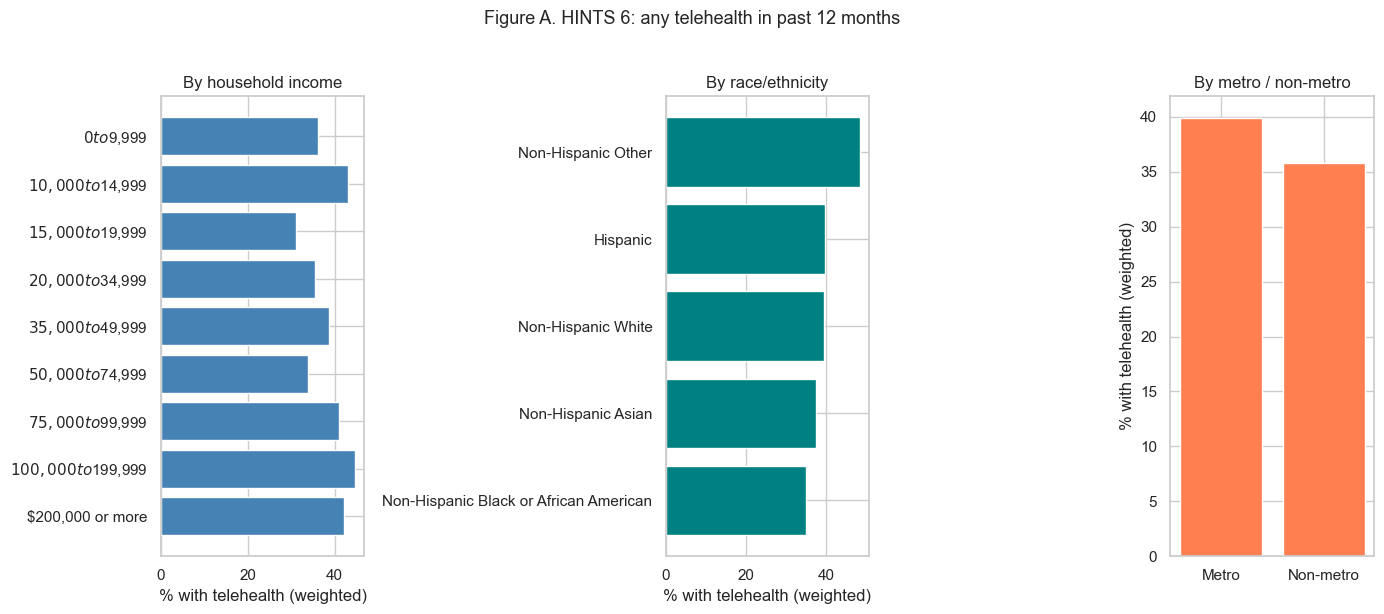

Figure A.1 HINTS - Any telehealth in past 12 months by household income (weighted %)
--------------------------------------------------------------------------------
              income       pct
        $0 to $9,999 36.237284
  $10,000 to $14,999 43.140303
  $15,000 to $19,999 31.187934
  $20,000 to $34,999 35.523234
  $35,000 to $49,999 38.689408
  $50,000 to $74,999 33.895250
  $75,000 to $99,999 41.022016
$100,000 to $199,999 44.621068
    $200,000 or more 42.204123

Figure A.2 HINTS - Any telehealth by race/ethnicity (weighted %)
--------------------------------------------------------------------
                                  race       pct
Non-Hispanic Black or African American 34.923666
                    Non-Hispanic Asian 37.491357
                    Non-Hispanic White 39.391207
                              Hispanic 39.703895
                    Non-Hispanic Other 48.340336

Figure A.3 HINTS - Any telehealth by metro status (weighted %)
-------------------------------

In [3]:
W = "PERSON_FINWT0"

fig, axes = plt.subplots(1, 3, figsize=(14, 6))

rows_inc = []
for inc in INCOME_ORDER:
    p = weighted_telehealth_pct(hints, "income_clean", inc, W)
    rows_inc.append((inc, p))
df_inc = pd.DataFrame(rows_inc, columns=["income", "pct"]).dropna(subset=["pct"])
axes[0].barh(df_inc["income"], df_inc["pct"], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_xlabel("% with telehealth (weighted)")
axes[0].set_title("By household income")

race_levels = [x for x in hints["race5"].dropna().unique() if str(x) != "nan"]
rows_r = []
for r in race_levels:
    p = weighted_telehealth_pct(hints, "race5", r, W)
    rows_r.append((r, p))
df_r = pd.DataFrame(rows_r, columns=["race", "pct"]).dropna(subset=["pct"])
df_r = df_r.sort_values("pct", ascending=True)
axes[1].barh(df_r["race"], df_r["pct"], color="teal")
axes[1].set_xlabel("% with telehealth (weighted)")
axes[1].set_title("By race/ethnicity")

rows_m = []
for m in ["Metro", "Non-metro"]:
    p = weighted_telehealth_pct(hints, "metro3", m, W)
    rows_m.append((m, p))
df_m = pd.DataFrame(rows_m, columns=["metro", "pct"]).dropna(subset=["pct"])
axes[2].bar(df_m["metro"], df_m["pct"], color="coral")
axes[2].set_ylabel("% with telehealth (weighted)")
axes[2].set_title("By metro / non-metro")

fig.suptitle("Figure A. HINTS 6: any telehealth in past 12 months", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

log_table("Figure A.1 HINTS - Any telehealth in past 12 months by household income (weighted %)", df_inc)
log_table("Figure A.2 HINTS - Any telehealth by race/ethnicity (weighted %)", df_r)
log_table("Figure A.3 HINTS - Any telehealth by metro status (weighted %)", df_m)


### Reader prompts — Figure A

1. **What does this chart show?** Weighted **prevalence of any past-year telehealth** among HINTS respondents, broken out by income, race/ethnicity, and broad metro geography.
2. **Why HINTS?** It asks directly about **telehealth utilization** with a national adult sampling frame suited to subgroup breakdowns.
3. **How should I interpret gaps between bars?** As **descriptive disparities** in reported use under the survey’s question wording and period—not as measures of access, quality, or need.
4. **Limitations:** Cross-sectional; telehealth definition is survey-specific; weights correct for the HINTS design but not for item nonresponse; small groups may be unstable.



## Figure B: How do telehealth users describe their experiences (HINTS 6)?

**Population:** Adults with `tele_status == 1` (reported any telehealth in the past 12 months).

**Items:** Agreement scales for whether telehealth was **good care**, whether they had **technology problems**, and whether they were **concerned about privacy** (exact field names in code).

**Estimation:** For each item, responses coded as missing/inapplicable-like are dropped; remaining answers are summarized as **weighted %** within users. Subtitles give **unweighted user n** for transparency.

**Use:** Describes **experiences among users**, not the full population and not clinical outcomes.



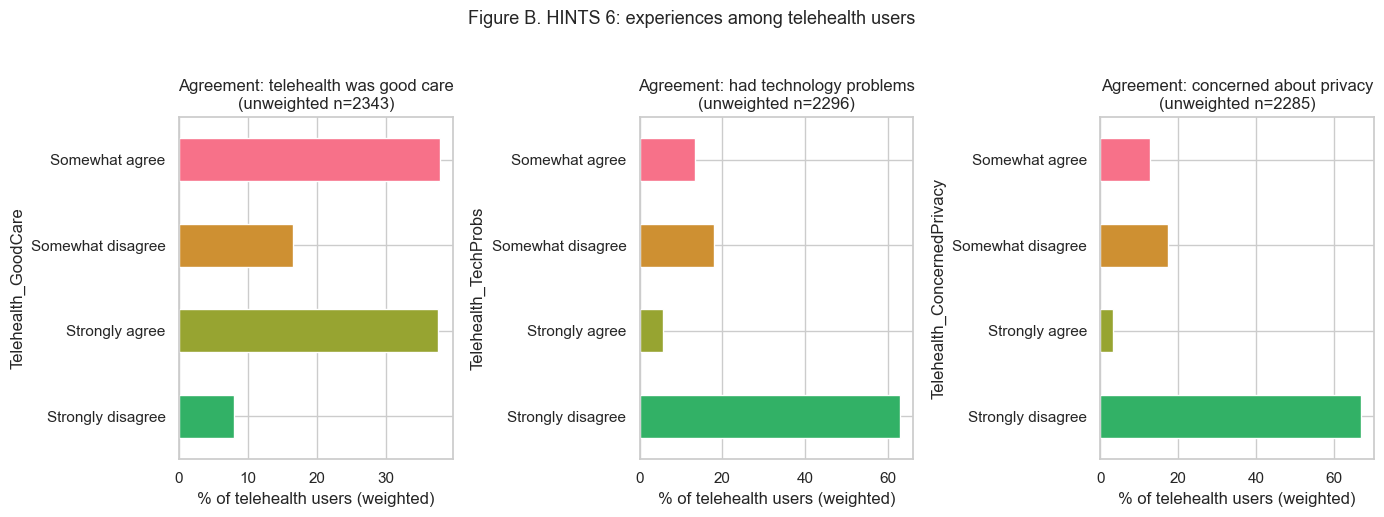

Figure B - Agreement: telehealth was good care (unweighted telehealth users n=2343)
--------------------------------------------------------------------------------
         response  weighted_pct
   Somewhat agree     37.831170
Somewhat disagree     16.484808
   Strongly agree     37.662861
Strongly disagree      8.021161

Figure B - Agreement: had technology problems (unweighted telehealth users n=2296)
--------------------------------------------------------------------------------
         response  weighted_pct
   Somewhat agree     13.467806
Somewhat disagree     17.891120
   Strongly agree      5.563308
Strongly disagree     63.077767

Figure B - Agreement: concerned about privacy (unweighted telehealth users n=2285)
--------------------------------------------------------------------------------
         response  weighted_pct
   Somewhat agree     12.701157
Somewhat disagree     17.269191
   Strongly agree      3.194564
Strongly disagree     66.835087



In [4]:
users = hints[hints["tele_status"] == 1].copy()

likert_cols = [
    ("Telehealth_GoodCare", "Agreement: telehealth was good care"),
    ("Telehealth_TechProbs", "Agreement: had technology problems"),
    ("Telehealth_ConcernedPrivacy", "Agreement: concerned about privacy"),
]


def weighted_likert_dist(df, col, w=W):
    s = df[col].astype(str)
    bad = s.str.contains("Inapplicable|Missing|error|Commission", case=False, na=False)
    sub = df.loc[~bad]
    n_unw = len(sub)
    if n_unw == 0:
        return None, n_unw
    vc = sub.groupby(col, observed=False)[w].sum()
    vc = vc / vc.sum() * 100
    return vc.sort_index(), n_unw


fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = sns.color_palette("husl", 8)
for ax, (col, title) in zip(axes, likert_cols):
    dist, n_unw = weighted_likert_dist(users, col)
    if dist is None:
        ax.set_visible(False)
        continue
    dist.plot(kind="barh", ax=ax, color=colors[: len(dist)])
    ax.set_xlabel("% of telehealth users (weighted)")
    ax.set_title(f"{title}\n(unweighted n={n_unw})")
    ax.invert_yaxis()
fig.suptitle("Figure B. HINTS 6: experiences among telehealth users", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

for col, title in likert_cols:
    dist, n_unw = weighted_likert_dist(users, col)
    if dist is None:
        log_table(f"Figure B - {title}", f"No valid responses (unweighted n={n_unw})")
        continue
    tbl = dist.reset_index()
    tbl.columns = ["response", "weighted_pct"]
    log_table(f"Figure B - {title} (unweighted telehealth users n={n_unw})", tbl)


### Reader prompts — Figure B

1. **What does this chart show?** Among **telehealth users**, how agreement is distributed on care quality, tech problems, and privacy concerns (HINTS, weighted among users).
2. **Why among users only?** The items target people who actually used telehealth; the full sample includes many non-users for whom items are not applicable.
3. **Interpretation:** High agreement on “good care” is **self-assessed satisfaction**, not independent quality measurement. Tech/privacy distributions highlight **implementation barriers** as perceived by respondents.
4. **Limitations:** Likert categories are coarse; social desirability; English-language survey context; counts differ slightly across items due to missingness.



## Figure C: Population patterns over time (Household Pulse)

**Data slice:** `Group == "National Estimate"` and `State == "United States"` / `Subgroup == "United States"`.

**Indicators plotted:** (1) **Received counseling or therapy** in the **last 4 weeks**, (2) **Needed counseling or therapy but did not get it** in the **last 4 weeks** (exact Pulse indicator strings in code).

**Display:** Line = point estimate `Value`; shaded band = `LowCI`–`HighCI` when present.

**Time axis:** `Time Period Start Date` parsed to `dt` (survey wave start).

**Contrast with HINTS:** Pulse refers to **4 weeks** and specific counseling items; HINTS Figure A refers to **12-month telehealth**. Periods and constructs differ—**do not** treat them as interchangeable.



Figure C - U.S. national series: Received counseling/therapy (last 4 wks)
-----------------------------------------------------------------------------
period_start  percent  low_ci  high_ci
  2020-08-19      8.7     8.3      9.2
  2020-09-02      9.1     8.7      9.5
  2020-09-16      9.0     8.7      9.4
  2020-09-30      9.0     8.7      9.4
  2020-10-14     10.0     9.5     10.5
  2020-10-28      9.8     9.4     10.2
  2020-11-11      9.9     9.5     10.3
  2020-11-25     10.1     9.6     10.6
  2020-12-09     10.2     9.7     10.7
  2020-12-22      NaN     NaN      NaN
  2021-01-06      9.6     9.2     10.1
  2021-01-20      9.8     9.4     10.1
  2021-02-03     10.3     9.8     10.7
  2021-02-17     10.3     9.9     10.7
  2021-03-03     10.6    10.1     11.0
  2021-03-17     10.1     9.6     10.6
  2021-03-30      NaN     NaN      NaN
  2021-04-14      9.8     9.4     10.3
  2021-04-28     10.2     9.8     10.6
  2021-05-12     10.0     9.5     10.4
  2021-05-26     10.1     9.7

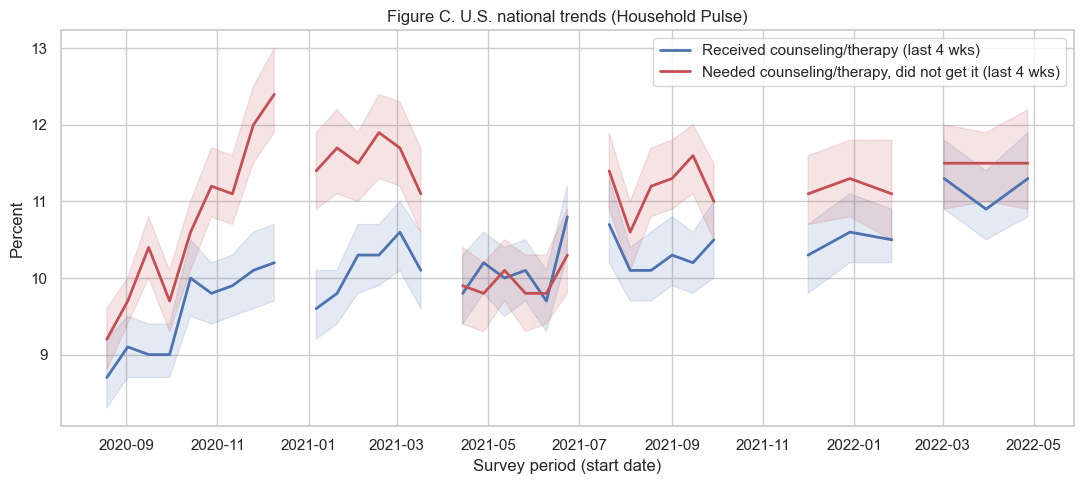

In [5]:
IND_COUNSEL = "Received Counseling or Therapy, Last 4 Weeks"
IND_UNMET = "Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks"

nat = pulse[
    (pulse["Group"] == "National Estimate")
    & (pulse["State"] == "United States")
    & (pulse["Subgroup"] == "United States")
].copy()

fig, ax = plt.subplots(figsize=(11, 5))
for ind, label, style in [
    (IND_COUNSEL, "Received counseling/therapy (last 4 wks)", "C0"),
    (IND_UNMET, "Needed counseling/therapy, did not get it (last 4 wks)", "C3"),
]:
    d = nat[nat["Indicator"] == ind].sort_values("dt")
    ax.plot(d["dt"], d["Value"], label=label, lw=2, color=style)
    if d["LowCI"].notna().any():
        ax.fill_between(d["dt"], d["LowCI"], d["HighCI"], alpha=0.15, color=style)
    cols = ["period_start", "percent", "low_ci", "high_ci"]
    out = d[["dt", "Value", "LowCI", "HighCI"]].rename(
        columns={"dt": "period_start", "Value": "percent", "LowCI": "low_ci", "HighCI": "high_ci"}
    )
    log_table(f"Figure C - U.S. national series: {label}", out)

ax.set_ylabel("Percent")
ax.set_xlabel("Survey period (start date)")
ax.set_title("Figure C. U.S. national trends (Household Pulse)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### Reader prompts — Figure C

1. **What does this chart show?** **National** Pulse estimates of recent counseling use and self-reported unmet counseling need, wave by wave.
2. **Why Pulse for time?** Pulse fielded **frequent repeated waves** during the pandemic era, supporting a national trajectory plot.
3. **Interpretation:** Changes may reflect true change, **mode/methodology shifts**, or compositional/nonresponse evolution—descriptive only.
4. **Limitations:** Short recall window (4 weeks); item wording is not identical to clinical diagnoses; missing waves appear as gaps/NaN in exported tables.



## Figure D: Place variation — one Household Pulse snapshot

**Goal:** Compare **states** on the same survey week to avoid mixing different fielding dates.

**Snapshot selection:** Among state rows for the combo indicator, compute how many states have non-missing `Value` per `dt`; take the **maximum** count, then choose the **latest** `dt` among ties (`best_dt`). This picks a **recent** week with **full (or maximal) geographic coverage**.

**Panels:** (1) **Took prescription medication for mental health and/or received counseling or therapy** (last 4 weeks), (2) **Needed counseling/therapy but did not get it** (last 4 weeks), same `best_dt`.

**Row filter:** `State == Subgroup` so estimates align to the state row (not a nested demographic breakdown).

**Exported tables:** Full state listing with `Value` and CIs where available, plus metadata (counts of states).



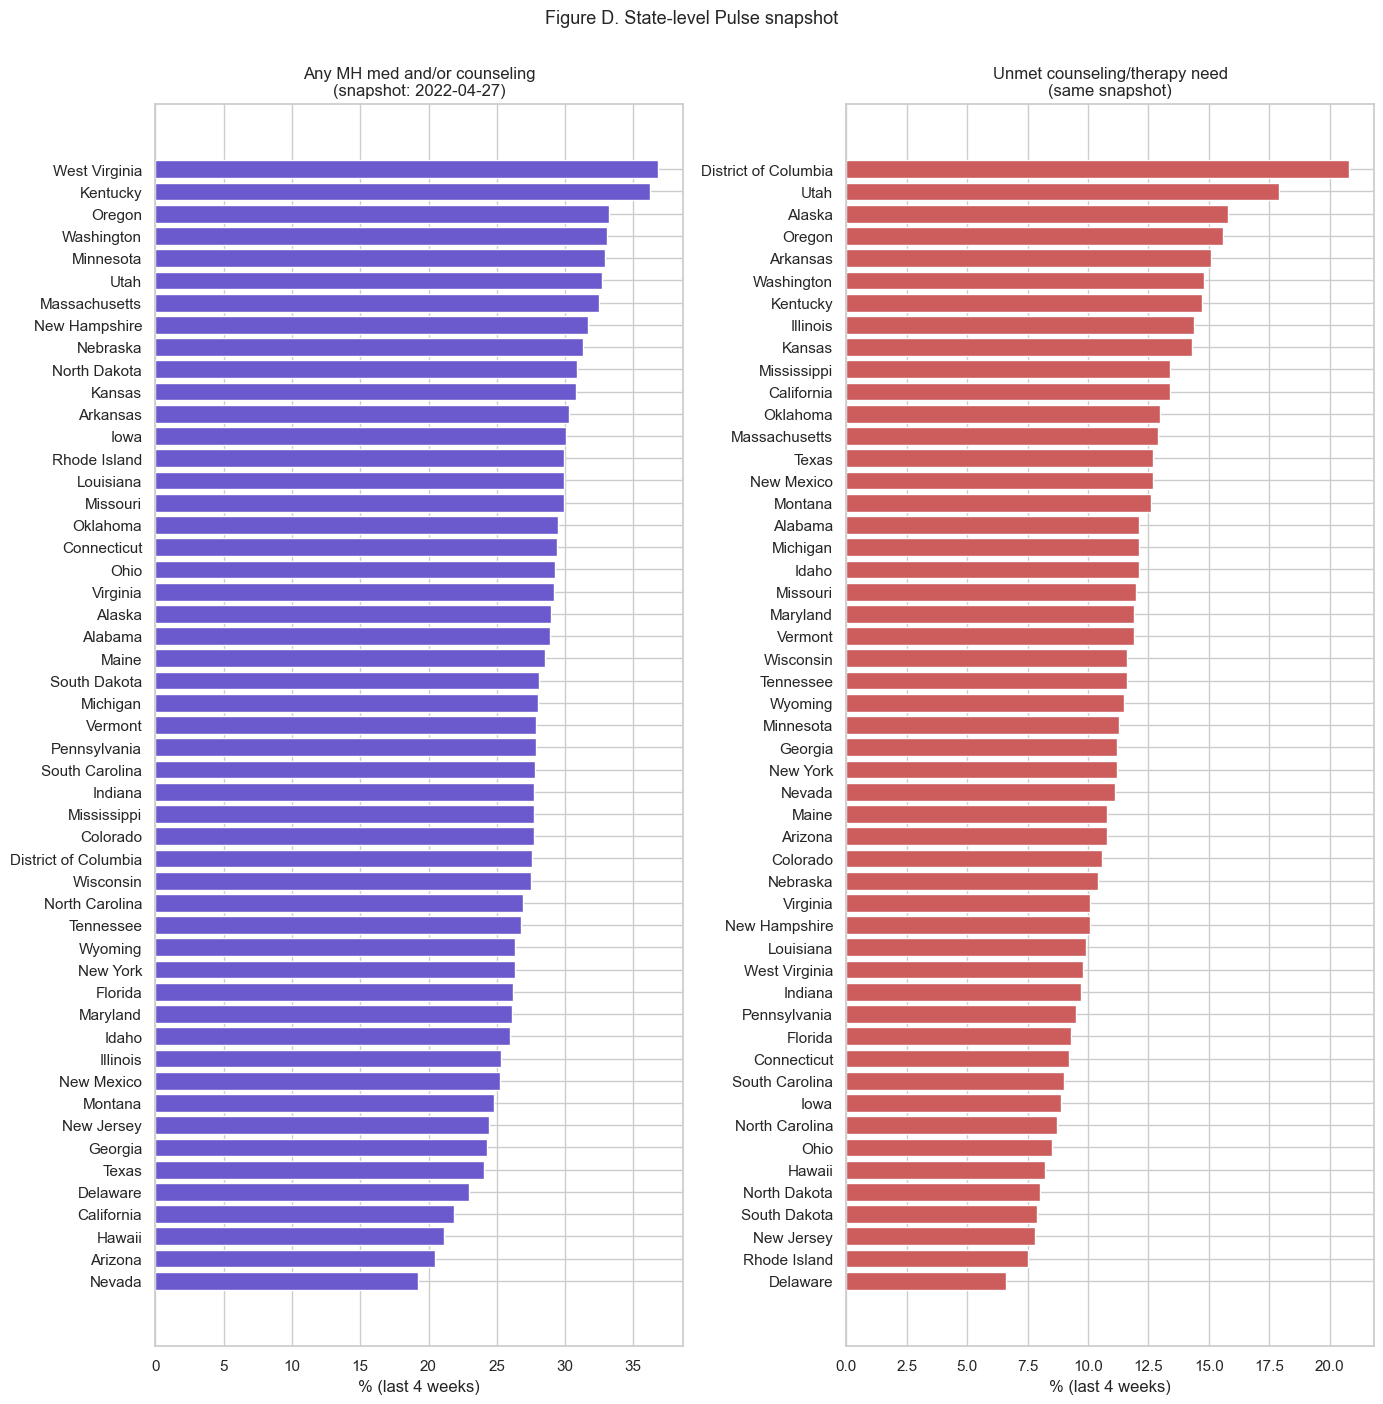

Snapshot date used: 2022-04-27 00:00:00
Figure D - Snapshot metadata (Household Pulse)
--------------------------------------------------
snapshot_start_date  states_with_combo_indicator  states_with_unmet_indicator
         2022-04-27                           51                           51

Figure D.1 - States: any MH med and/or counseling (same snapshot)
---------------------------------------------------------------------
               State  pct_combo  low_ci  high_ci
              Nevada       19.2    15.5     23.3
             Arizona       20.5    17.7     23.5
              Hawaii       21.1    15.7     27.4
          California       21.9    19.2     24.9
            Delaware       23.0    18.3     28.3
               Texas       24.1    21.3     27.0
             Georgia       24.3    21.2     27.7
          New Jersey       24.4    21.0     28.0
             Montana       24.8    20.7     29.3
          New Mexico       25.2    21.3     29.5
            Illinois       25.

In [6]:
IND_COMBO = (
    "Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks"
)
st_all = pulse[(pulse["Group"] == "By State") & (pulse["Indicator"] == IND_COMBO)].copy()
counts = st_all.groupby("dt")["Value"].apply(lambda x: x.notna().sum())
max_n = counts.max()
best_dt = counts[counts == max_n].index.max()
snap = st_all[st_all["dt"] == best_dt].dropna(subset=["Value"]).copy()
snap = snap[snap["State"] == snap["Subgroup"]]
snap = snap.sort_values("Value", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 14))
axes[0].barh(snap["State"], snap["Value"], color="slateblue")
axes[0].set_xlabel("% (last 4 weeks)")
axes[0].set_title(f"Any MH med and/or counseling\n(snapshot: {best_dt.date()})")

IND_UNMET_D = "Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks"
st_u = pulse[(pulse["Group"] == "By State") & (pulse["Indicator"] == IND_UNMET_D)].copy()
snap_u = st_u[st_u["dt"] == best_dt].dropna(subset=["Value"])
snap_u = snap_u[snap_u["State"] == snap_u["Subgroup"]].sort_values("Value", ascending=True)
axes[1].barh(snap_u["State"], snap_u["Value"], color="indianred")
axes[1].set_xlabel("% (last 4 weeks)")
axes[1].set_title("Unmet counseling/therapy need\n(same snapshot)")

fig.suptitle("Figure D. State-level Pulse snapshot", fontsize=13, y=1.002)
plt.tight_layout()
plt.show()
print("Snapshot date used:", best_dt)

meta = pd.DataFrame(
    {
        "snapshot_start_date": [str(best_dt.date())],
        "states_with_combo_indicator": [snap["State"].nunique()],
        "states_with_unmet_indicator": [snap_u["State"].nunique()],
    }
)
log_table("Figure D - Snapshot metadata (Household Pulse)", meta)
combo_tbl = snap[["State", "Value", "LowCI", "HighCI"]].rename(
    columns={"Value": "pct_combo", "LowCI": "low_ci", "HighCI": "high_ci"}
)
log_table("Figure D.1 - States: any MH med and/or counseling (same snapshot)", combo_tbl)
unmet_tbl = snap_u[["State", "Value", "LowCI", "HighCI"]].rename(
    columns={"Value": "pct_unmet_need", "LowCI": "low_ci", "HighCI": "high_ci"}
)
log_table("Figure D.2 - States: unmet counseling/therapy need (same snapshot)", unmet_tbl)


### Reader prompts — Figure D

1. **What does this chart show?** **State rankings** from a **single Pulse week** for combined recent MH treatment/counseling and for unmet counseling need.
2. **Why one snapshot?** Pulse is high-frequency; pooling arbitrary weeks would blur interpretation. The code picks a principled **latest high-coverage** date.
3. **Interpretation:** Ranks are **ecological** summaries for one window—useful for pattern-spotting, not for attributing causes to state policies.
4. **Limitations:** Small states have wider CIs; part-year fielding; indicator combines medication and/or counseling—components are not separated here.



## Figure E: State context — NSDUH small-area estimates (Table 37)

**Measure:** Modeled **percent of adults 18+** who **received any mental health treatment in the past year** (NSDUH SAE documentation defines “treatment”).

**Source file:** `NSDUHsaeExcelTab37-2023.csv` with Excel-style leading rows skipped so `State` parses correctly.

**Display:** States ordered from **low to high** modeled percentage.

**Relationship to Pulse:** NSDUH is **past-year treatment** and modeled at state level; Pulse Figure D is **last 4 weeks** self-report—conceptually related but **not** the same construct or timeframe.



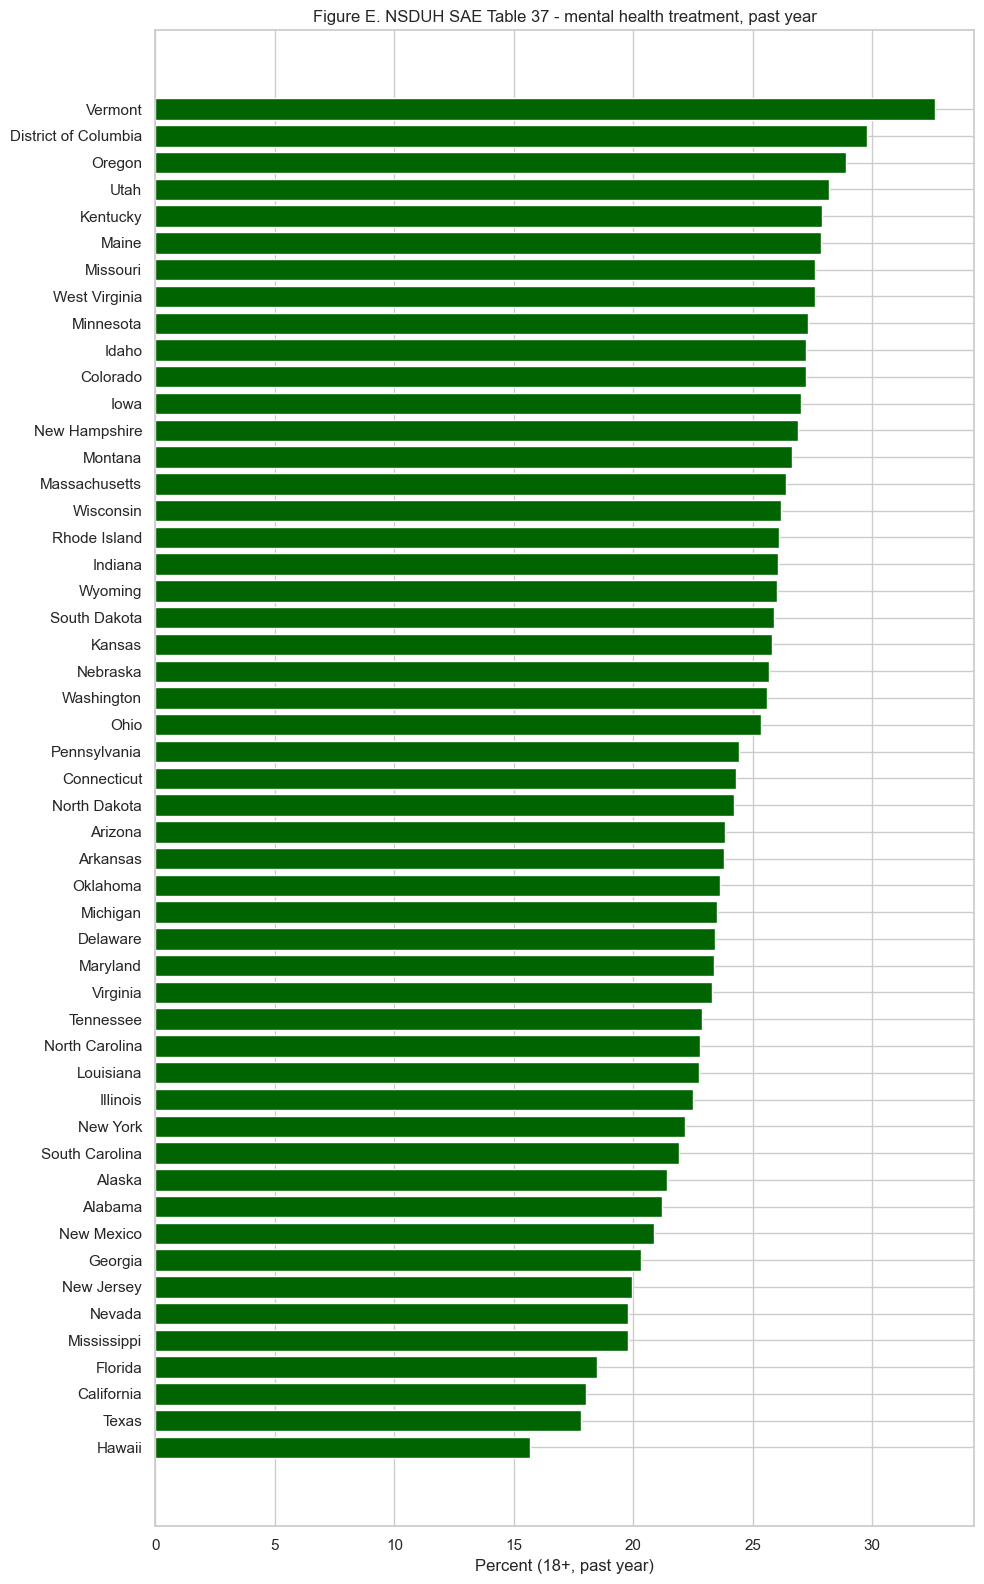

Figure E - NSDUH Table 37: percent 18+ with past-year mental health treatment by state
--------------------------------------------------------------------------------
               State  pct_18p
              Hawaii    15.69
               Texas    17.83
          California    18.02
             Florida    18.48
         Mississippi    19.78
              Nevada    19.79
          New Jersey    19.93
             Georgia    20.33
          New Mexico    20.88
             Alabama    21.20
              Alaska    21.40
      South Carolina    21.91
            New York    22.15
            Illinois    22.48
           Louisiana    22.74
      North Carolina    22.80
           Tennessee    22.89
            Virginia    23.28
            Maryland    23.36
            Delaware    23.40
            Michigan    23.52
            Oklahoma    23.62
            Arkansas    23.81
             Arizona    23.85
        North Dakota    24.23
         Connecticut    24.32
        Pennsylvania  

In [7]:
ns = nsduh_states.sort_values("pct_18p", ascending=True)

fig, ax = plt.subplots(figsize=(10, 16))
ax.barh(ns["State"], ns["pct_18p"], color="darkgreen")
ax.set_xlabel("Percent (18+, past year)")
ax.set_title("Figure E. NSDUH SAE Table 37 - mental health treatment, past year")
plt.tight_layout()
plt.show()

log_table("Figure E - NSDUH Table 37: percent 18+ with past-year mental health treatment by state", ns[["State", "pct_18p"]])


### Reader prompts — Figure E

1. **What does this chart show?** **Modeled state prevalence** of past-year mental health treatment from NSDUH SAEs.
2. **Why NSDUH here?** Provides a **population mental health service use** lens at state level from a different methodology than Pulse.
3. **Interpretation:** Higher bars mean **higher modeled prevalence** under the SAE model—not necessarily higher quality or access.
4. **Limitations:** Model-based uncertainty intervals are not plotted in the notebook figure; estimates borrow information across areas; 2023 table may not align in calendar time with the Pulse snapshot.



## Figure F (optional): Ecological association — Pulse snapshot vs NSDUH

**Merge:** Inner join of **states** from Figure D’s Pulse snapshot (combined med/counseling indicator) with **Figure E’s** NSDUH `pct_18p` on `State`.

**Plot:** Scatter with a few **high and low Pulse** states labeled for readability.

**Exported statistics:** Pearson correlation between the two **state-level** percentages and the full merged table.

**Critical caution:** This is an **ecological** comparison: two different surveys, different reference periods (4 weeks vs past year), and different question constructs. **Correlation does not imply causation** and does not generalize to individuals.



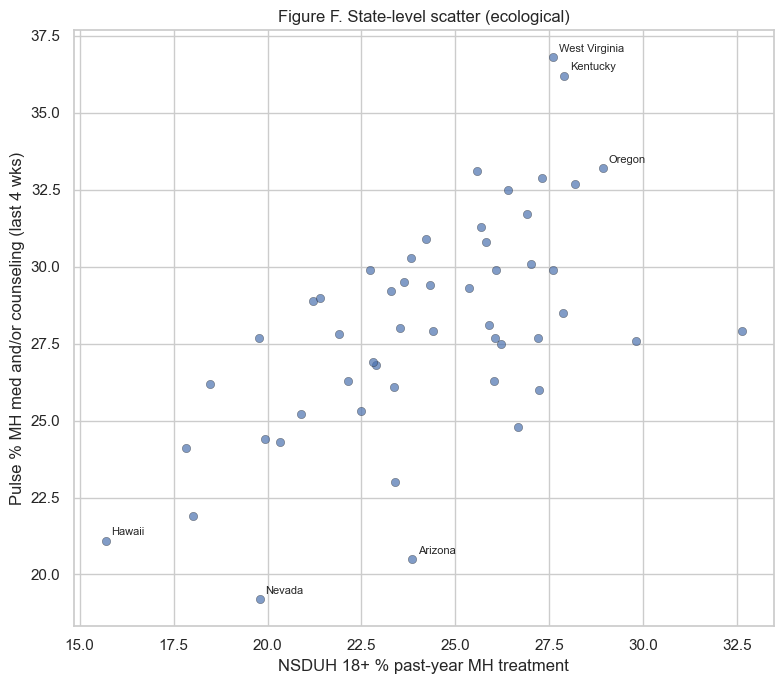

Figure F - Ecological scatter summary
-----------------------------------------
 n_states_in_plot  pearson_r_nsduh_vs_pulse_combo
               51                        0.600272

Figure F - State-level values (NSDUH vs Pulse combo indicator)
------------------------------------------------------------------
               State  nsduh_18p_pct  pulse_combo_pct
             Alabama          21.20             28.9
              Alaska          21.40             29.0
             Arizona          23.85             20.5
            Arkansas          23.81             30.3
          California          18.02             21.9
            Colorado          27.21             27.7
         Connecticut          24.32             29.4
            Delaware          23.40             23.0
District of Columbia          29.80             27.6
             Florida          18.48             26.2
             Georgia          20.33             24.3
              Hawaii          15.69             21.1


In [8]:
merge = snap.merge(
    nsduh_states[["State", "pct_18p"]], on="State", how="inner", suffixes=("_pulse", "")
)
merge = merge.rename(columns={"Value": "pulse_combo_pct", "pct_18p": "nsduh_18p_pct"})

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(
    merge["nsduh_18p_pct"],
    merge["pulse_combo_pct"],
    alpha=0.7,
    edgecolors="k",
    linewidths=0.3,
)
for _, row in merge.nlargest(3, "pulse_combo_pct").iterrows():
    ax.annotate(
        row["State"],
        (row["nsduh_18p_pct"], row["pulse_combo_pct"]),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points",
    )
for _, row in merge.nsmallest(3, "pulse_combo_pct").iterrows():
    ax.annotate(
        row["State"],
        (row["nsduh_18p_pct"], row["pulse_combo_pct"]),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points",
    )

ax.set_xlabel("NSDUH 18+ % past-year MH treatment")
ax.set_ylabel("Pulse % MH med and/or counseling (last 4 wks)")
ax.set_title("Figure F. State-level scatter (ecological)")
plt.tight_layout()
plt.show()

r = merge["nsduh_18p_pct"].corr(merge["pulse_combo_pct"])
summary = pd.DataFrame(
    {
        "n_states_in_plot": [len(merge)],
        "pearson_r_nsduh_vs_pulse_combo": [r],
    }
)
log_table("Figure F - Ecological scatter summary", summary)
pairs = merge[["State", "nsduh_18p_pct", "pulse_combo_pct"]].sort_values("State")
log_table("Figure F - State-level values (NSDUH vs Pulse combo indicator)", pairs)


### Reader prompts — Figure F

1. **What does this chart show?** **State-level** pairing of Pulse “recent med/counseling or therapy” % vs NSDUH past-year mental health treatment %.
2. **Why include it?** To visualize **coarse alignment** (or lack thereof) between rapid Pulse indicators and annual modeled treatment prevalence—useful for hypothesis generation only.
3. **Interpretation:** A positive correlation might reflect **shared state-level factors** (reporting, capacity, demographics) or **artifact**—cannot be separated here.
4. **Limitations:** Two surveys, two timeframes, two concepts; no covariate adjustment; D.C. and small states behave differently; outliers drive correlation.



In [9]:
# Write plain-text tables + full metadata preamble (UTF-8)
out_path = BASE / "visualization_summaries.txt"
preamble = build_documentation_preamble(hints, pulse, nsduh_states, nsduh_raw)
body = "\n".join(SUMMARY_BLOCKS)
out_path.write_text(preamble + body, encoding="utf-8")
print(
    f"Wrote {out_path.resolve()}\n"
    f"  Preamble (metadata): ~{len(preamble):,} chars\n"
    f"  Table sections: {len(SUMMARY_BLOCKS)}\n"
    f"  Total file size: {out_path.stat().st_size:,} bytes"
)


Wrote /Users/dvgenis/Desktop/IS308/visualization_summaries.txt
  Preamble (metadata): ~5,055 chars
  Table sections: 14
  Total file size: 21,186 bytes
